In [ ]:
import pandas as pd
import numpy as np
from scipy.cluster.hierarchy import linkage, fcluster
import matplotlib.pyplot as plt

In [25]:
GO_BP = pd.read_csv('data/gene_go_matrix_propT_rel-is_a-part_of_ont-BP.csv', index_col=0)
GO_CC = pd.read_csv('data/gene_go_matrix_propT_rel-is_a-part_of_ont-CC.csv', index_col=0)
GO_MF = pd.read_csv('data/gene_go_matrix_propT_rel-is_a-part_of_ont-MF.csv', index_col=0)
HPO   = pd.read_csv('data/gene_hpo_matrix_binary_withAncestors_namespace_Phenotypic abnormality.csv', index_col=0)

In [2]:
view1 = pd.read_csv('clusters/GO_BP-clusters.csv')
view2 = pd.read_csv('clusters/GO_MF-clusters.csv')
view3 = pd.read_csv('clusters/GO_CC-clusters.csv')
view4 = pd.read_csv('clusters/HPO-clusters.csv')
mofa = pd.read_csv('clusters/mofa-clusters.csv')

clusterings = {
    'GO_BP': view1,
    'GO_MF': view2,
    'GO_CC': view3,
    'HPO': view4,
    'MOFA': mofa
}

In [8]:
def build_coassignment_matrix(clusterings, views_to_include=None, ks_to_include=None):
    """
    Build the co-assignment matrix from multiple clusterings.

    Parameters
    ----------
    clusterings : dict
        {view_name: DataFrame with shape (n_samples, n_k)}
    views_to_include : list of str, optional
        Which views to include (default all)
    ks_to_include : list of int, optional
        Which k values to include (default all ks in clusterings)

    Returns
    -------
    coassign : np.ndarray, shape (n_samples, n_samples)
        Fraction of clusterings in which each pair of samples is in the same cluster
    """
    if views_to_include is None:
        views_to_include = list(clusterings.keys())

    # Determine ks
    if ks_to_include is None:
        # use all columns in first view
        ks_to_include = [int(c) for c in clusterings[views_to_include[0]].columns]

    n_samples = clusterings[views_to_include[0]].shape[0]
    coassign = np.zeros((n_samples, n_samples), dtype=float)
    n_total = 0

    for view in views_to_include:
        df = clusterings[view]
        for k in ks_to_include:
            labels = df[str(k)].values.ravel()
            # build co-assignment for this clustering
            for i in range(n_samples):
                for j in range(i, n_samples):
                    if labels[i] == labels[j]:
                        coassign[i, j] += 1
                        if i != j:
                            coassign[j, i] += 1
            n_total += 1

    coassign /= n_total
    return coassign


def consensus_clustering(coassign_matrix, n_clusters=10, method='average'):
    """
    Compute consensus clusters using hierarchical clustering.

    Parameters
    ----------
    coassign_matrix : np.ndarray
        n_samples x n_samples co-assignment matrix
    n_clusters : int
        Number of consensus clusters
    method : str
        Linkage method for hierarchical clustering (default 'average')

    Returns
    -------
    labels : np.ndarray, shape (n_samples,)
        Consensus cluster labels (1..n_clusters)
    """
    # Convert similarity to distance
    distance = 1.0 - coassign_matrix

    # Condensed distance matrix for linkage
    from scipy.spatial.distance import squareform
    dist_condensed = squareform(distance, checks=False)

    Z = linkage(dist_condensed, method=method)
    labels = fcluster(Z, t=n_clusters, criterion='maxclust')
    return labels

Best number of clusters according to ΔCDF: 9


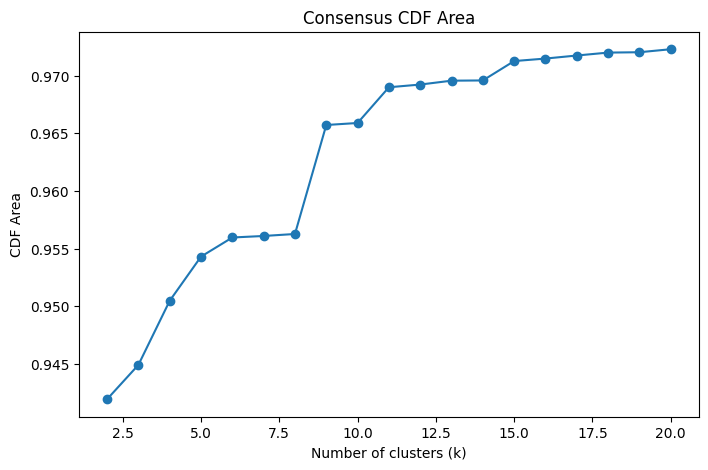

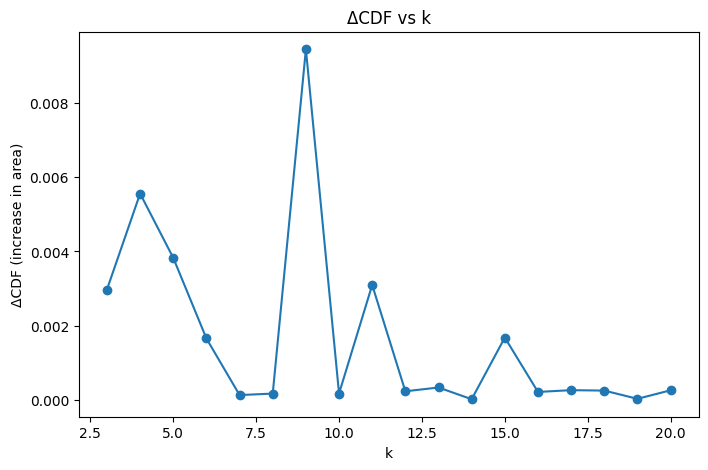

In [ ]:
def consensus_cdf(consensus_matrix, bins=100):
    """
    Compute CDF of consensus values (upper triangle excluding diagonal).
    """
    vals = consensus_matrix[np.triu_indices_from(consensus_matrix, k=1)]
    hist, bin_edges = np.histogram(vals, bins=bins, range=(0,1), density=True)
    cdf = np.cumsum(hist) / np.sum(hist)
    return cdf, bin_edges[1:]  # cdf values and x-axis


def compute_cdf_scores(coassign_matrix, k_range):
    """
    For each k, compute:
      - consensus labels
      - within-cluster consensus scores
      - CDF area
    Returns dict of results.
    """
    results = {}
    distance = 1 - coassign_matrix

    for k in k_range:
        labels = consensus_clustering(coassign_matrix, n_clusters=k)

        # Build consensus matrix for clusters only
        n = len(labels)
        consensus_within = np.zeros((n, n))

        for i in range(n):
            for j in range(n):
                if labels[i] == labels[j]:
                    consensus_within[i, j] = coassign_matrix[i, j]

        # CDF of within-cluster agreement
        cdf, bins = consensus_cdf(consensus_within)
        auc = np.trapz(cdf, bins)   # area under CDF curve

        results[k] = {
            "labels": labels,
            "cdf": cdf,
            "bins": bins,
            "auc": auc,
        }

    return results


def find_optimal_k(cdf_results):
    """
    Choose optimal k using ΔCDF method.
    """
    ks = sorted(cdf_results.keys())
    aucs = [cdf_results[k]['auc'] for k in ks]

    deltas = np.diff(aucs)
    best_idx = np.argmax(deltas)  # biggest jump
    best_k = ks[best_idx + 1]     # delta is between k and k+1

    return best_k, ks, aucs, deltas

coassign = build_coassignment_matrix(clusterings,
                                     views_to_include=["HPO","GO_CC","GO_BP","GO_MF","MOFA"],
                                     ks_to_include=range(20,51))  # pick stable ks

k_range = range(2, 21)

cdf_results = compute_cdf_scores(coassign, k_range)
best_k, ks, aucs, deltas = find_optimal_k(cdf_results)

print("Best number of clusters according to ΔCDF:", best_k)

# Plot AUC
plt.figure(figsize=(8,5))
plt.plot(ks, aucs, "-o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("CDF Area")
plt.title("Consensus CDF Area")
plt.show()

# Plot ΔCDF
plt.figure(figsize=(8,5))
plt.plot(ks[1:], deltas, "-o")
plt.xlabel("k")
plt.ylabel("ΔCDF (increase in area)")
plt.title("ΔCDF vs k")
plt.show()


In [11]:
# Step 2: compute consensus clusters
n_consensus_clusters = best_k
consensus_labels = consensus_clustering(coassign, n_clusters=n_consensus_clusters)

# Step 3: view results
print("Consensus cluster counts:")
print(pd.Series(consensus_labels).value_counts())

Consensus cluster counts:
9    1840
8    1343
1     554
4     458
2     314
6     239
7     175
5     162
3      98
Name: count, dtype: int64


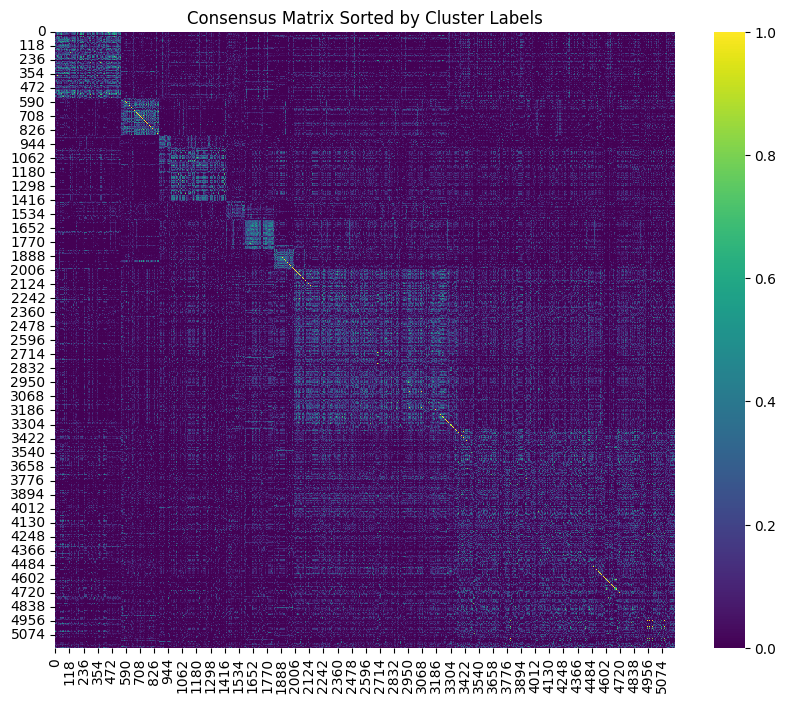

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

order = np.argsort(consensus_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(coassign[order][:, order], cmap="viridis")
plt.title("Consensus Matrix Sorted by Cluster Labels")
plt.show()


In [45]:
strength = {}

for k in consensus_labels:
    idx = np.where(consensus_labels == k)[0]
    sub = coassign[np.ix_(idx, idx)]
    vals = sub[np.triu_indices(len(idx), k=1)]
    strength[k] = vals.mean()

strength


{8: 0.1369577175735043,
 9: 0.09168234687581744,
 6: 0.27150331586271975,
 7: 0.25839843212034536,
 3: 0.221586366505365,
 4: 0.17762935760360737,
 5: 0.1530438740349914,
 1: 0.1788325891508064,
 2: 0.21398254266360592}

In [46]:
# keep only strong clusters
strong_clusters = [k for k, s in strength.items() if s > 0.20]
strong_clusters


[6, 7, 3, 2]

In [39]:
genes = GO_BP.index.to_numpy()

gene_to_cluster = pd.DataFrame({
    "gene": genes,
    "cluster": consensus_labels
})

clusters = {
    k: gene_to_cluster.loc[gene_to_cluster["cluster"] == k, "gene"].tolist()
    for k in sorted(gene_to_cluster["cluster"].unique())
}

In [43]:
GO_BP_cluster_profiles = {}

for k, gene_list in clusters.items():
    GO_BP_cluster_profiles[k] = GO_BP.loc[gene_list].sum().sort_values(ascending=False)

GO_BP_cluster_profiles[k].head(10)

GO.0008150    1815
GO.0008152    1260
GO.0009058     789
GO.0050896     673
GO.0032502     598
GO.0006139     574
GO.0048856     557
GO.0006996     544
GO.0051179     538
GO.0019222     511
dtype: int64